In [107]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from pgmpy.models.BayesianNetwork import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import VariableElimination
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pgmpy.estimators import PC
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.models import DiscreteBayesianNetwork


In [108]:
users = pd.read_csv('users.dat', sep='::', engine='python', names=['user_id', 'gender', 'age', 'occupation', 'zip_code'], encoding='latin-1')
movies = pd.read_csv('movies.dat', sep='::', engine='python', names=['movie_id', 'title', 'genres'], encoding='latin-1')
ratings = pd.read_csv('ratings.dat', sep='::', engine='python', names=['user_id', 'movie_id', 'rating', 'timestamp'], encoding='latin-1')


In [109]:
users.head()

,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [111]:
movies.head()

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [112]:
print(users.isnull().sum())
print(movies.isnull().sum())
print(ratings.isnull().sum())


user_id       0
gender        0
age           0
occupation    0
zip_code      0
dtype: int64
movie_id    0
title       0
genres      0
dtype: int64
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64


In [113]:
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['year'] = pd.to_numeric(movies['year'], errors='coerce')


In [114]:
users = users[['user_id', 'gender', 'age','occupation']]
movies = movies[['movie_id', 'genres', 'year','title']]
ratings = ratings[['user_id', 'movie_id', 'rating']]

In [ ]:
movies.head()

,movie_id,genres,year,title
0,1,Animation|Children's|Comedy,1995,Toy Story (1995)
1,2,Adventure|Children's|Fantasy,1995,Jumanji (1995)
2,3,Comedy|Romance,1995,Grumpier Old Men (1995)
3,4,Comedy|Drama,1995,Waiting to Exhale (1995)
4,5,Comedy,1995,Father of the Bride Part II (1995)


In [116]:
ratings

,user_id,movie_id,rating
0,1,1193,5
1,1,661,3
2,1,914,3
3,1,3408,4
4,1,2355,5
...,...,...,...
1000204,6040,1091,1
1000205,6040,1094,5
1000206,6040,562,5
1000207,6040,1096,4


In [117]:
print(users.isnull().sum())
print(movies.isnull().sum())
print(ratings.isnull().sum())


user_id       0
gender        0
age           0
occupation    0
dtype: int64
movie_id    0
genres      0
year        0
title       0
dtype: int64
user_id     0
movie_id    0
rating      0
dtype: int64


In [118]:

movies = movies.assign(genres=movies['genres'].str.split('|')).explode('genres')

print(movies.head())

   movie_id      genres  year             title
0         1   Animation  1995  Toy Story (1995)
0         1  Children's  1995  Toy Story (1995)
0         1      Comedy  1995  Toy Story (1995)
1         2   Adventure  1995    Jumanji (1995)
1         2  Children's  1995    Jumanji (1995)


In [119]:
duplicate_movies = movies[movies.duplicated(subset='movie_id', keep=False)]
print(duplicate_movies)


      movie_id      genres  year                  title
0            1   Animation  1995       Toy Story (1995)
0            1  Children's  1995       Toy Story (1995)
0            1      Comedy  1995       Toy Story (1995)
1            2   Adventure  1995         Jumanji (1995)
1            2  Children's  1995         Jumanji (1995)
...        ...         ...   ...                    ...
3876      3946      Action  2000      Get Carter (2000)
3876      3946       Drama  2000      Get Carter (2000)
3876      3946    Thriller  2000      Get Carter (2000)
3882      3952       Drama  2000  Contender, The (2000)
3882      3952    Thriller  2000  Contender, The (2000)

[4383 rows x 4 columns]


In [120]:
def discretize_year_numeric(year):
    if year < 1980:
        return 0
    elif year < 1990:
        return 1
    elif year < 2000:
        return 2
    elif year < 2010:
        return 3
    elif year < 2020:
        return 4
    else:
        return 5


movies['year'] = movies['year'].apply(discretize_year_numeric)


In [121]:
movies['year']

0       2
0       2
0       2
1       2
1       2
       ..
3879    3
3880    3
3881    3
3882    3
3882    3
Name: year, Length: 6408, dtype: int64

In [122]:
label_encoder = LabelEncoder()
users['gender'] = label_encoder.fit_transform(users['gender'])
print(users.head())

   user_id  gender  age  occupation
0        1       0    1          10
1        2       1   56          16
2        3       1   25          15
3        4       1   45           7
4        5       1   25          20


In [123]:
one_hot = pd.get_dummies(movies['genres'])

df_encoded = pd.concat([movies[['movie_id', 'year','title']], one_hot], axis=1)

movies = df_encoded.groupby(['movie_id', 'year']).max().reset_index()

movies.head()

,movie_id,year,title,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,2,Toy Story (1995),False,False,True,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,2,Jumanji (1995),False,True,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,3,2,Grumpier Old Men (1995),False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
3,4,2,Waiting to Exhale (1995),False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,2,Father of the Bride Part II (1995),False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [124]:
ratings.columns

Index(['user_id', 'movie_id', 'rating'], dtype='object')

In [125]:

user_avg = ratings.groupby('user_id')['rating'].mean().reset_index(name='avg_rating')

user_high_ratio = (ratings['rating'] >= 4).groupby(ratings['user_id']).mean().reset_index(name='high_rating_ratio')

user_std = ratings.groupby('user_id')['rating'].std().reset_index(name='std_rating')


user_min = ratings.groupby('user_id')['rating'].min().reset_index(name='min_rating')
user_max = ratings.groupby('user_id')['rating'].max().reset_index(name='max_rating')

user_stats = user_avg.merge(user_high_ratio, on='user_id') \
                     .merge(user_std, on='user_id') \
                     .merge(user_min, on='user_id') \
                     .merge(user_max, on='user_id')

user_stats['binned_avg_rating'] = pd.cut(user_stats['avg_rating'], bins=[0,1,2,3,4,5], labels=[1,2,3,4,5])
user_stats['binned_high_rating_ratio'] = pd.cut(user_stats['high_rating_ratio'], bins=[0,0.2,0.4,0.6,0.8,1], labels=[1,2,3,4,5], include_lowest=True)
user_stats['binned_std_rating'] = pd.cut(user_stats['std_rating'], bins=[0,0.5,1,1.5,2,5], labels=[1,2,3,4,5])
user_stats['binned_min_rating'] = pd.cut(user_stats['min_rating'], bins=[0,1,2,3,4,5], labels=[1,2,3,4,5])
user_stats['binned_max_rating'] = pd.cut(user_stats['max_rating'], bins=[0,1,2,3,4,5], labels=[1,2,3,4,5])

user_binned = user_stats[['user_id',
                          'binned_avg_rating',
                          'binned_high_rating_ratio',
                          'binned_std_rating',
                          'binned_min_rating',
                          'binned_max_rating']]


ratings = ratings.merge(user_binned, on='user_id', how='left')


In [126]:
ratings

,user_id,movie_id,rating,binned_avg_rating,binned_high_rating_ratio,binned_std_rating,binned_min_rating,binned_max_rating
0,1,1193,5,5,5,2,3,5
1,1,661,3,5,5,2,3,5
2,1,914,3,5,5,2,3,5
3,1,3408,4,5,5,2,3,5
4,1,2355,5,5,5,2,3,5
...,...,...,...,...,...,...,...,...
1000204,6040,1091,1,4,4,3,1,5
1000205,6040,1094,5,4,4,3,1,5
1000206,6040,562,5,4,4,3,1,5
1000207,6040,1096,4,4,4,3,1,5


In [127]:
ratings = ratings.reset_index(drop=True)
users = users.drop_duplicates(subset='user_id').reset_index(drop=True)
movies = movies.drop_duplicates(subset='movie_id').reset_index(drop=True)


full_data = ratings.merge(users, on='user_id', how='left')


full_data = full_data.merge(movies, on='movie_id', how='left')


In [128]:
full_data.columns

Index(['user_id', 'movie_id', 'rating', 'binned_avg_rating',
       'binned_high_rating_ratio', 'binned_std_rating', 'binned_min_rating',
       'binned_max_rating', 'gender', 'age', 'occupation', 'year', 'title',
       'Action', 'Adventure', 'Animation', 'Children's', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
       'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'],
      dtype='object')

In [129]:
full_data['high_rating'] = full_data['rating'].apply(lambda x: 1 if x >= 4 else 0)


In [130]:
train_data, test_data = train_test_split(full_data, test_size=0.2, random_state=42)

In [131]:
train_data=train_data.drop(columns=["title"])

In [292]:
full_data=full_data.drop(columns=["title"])

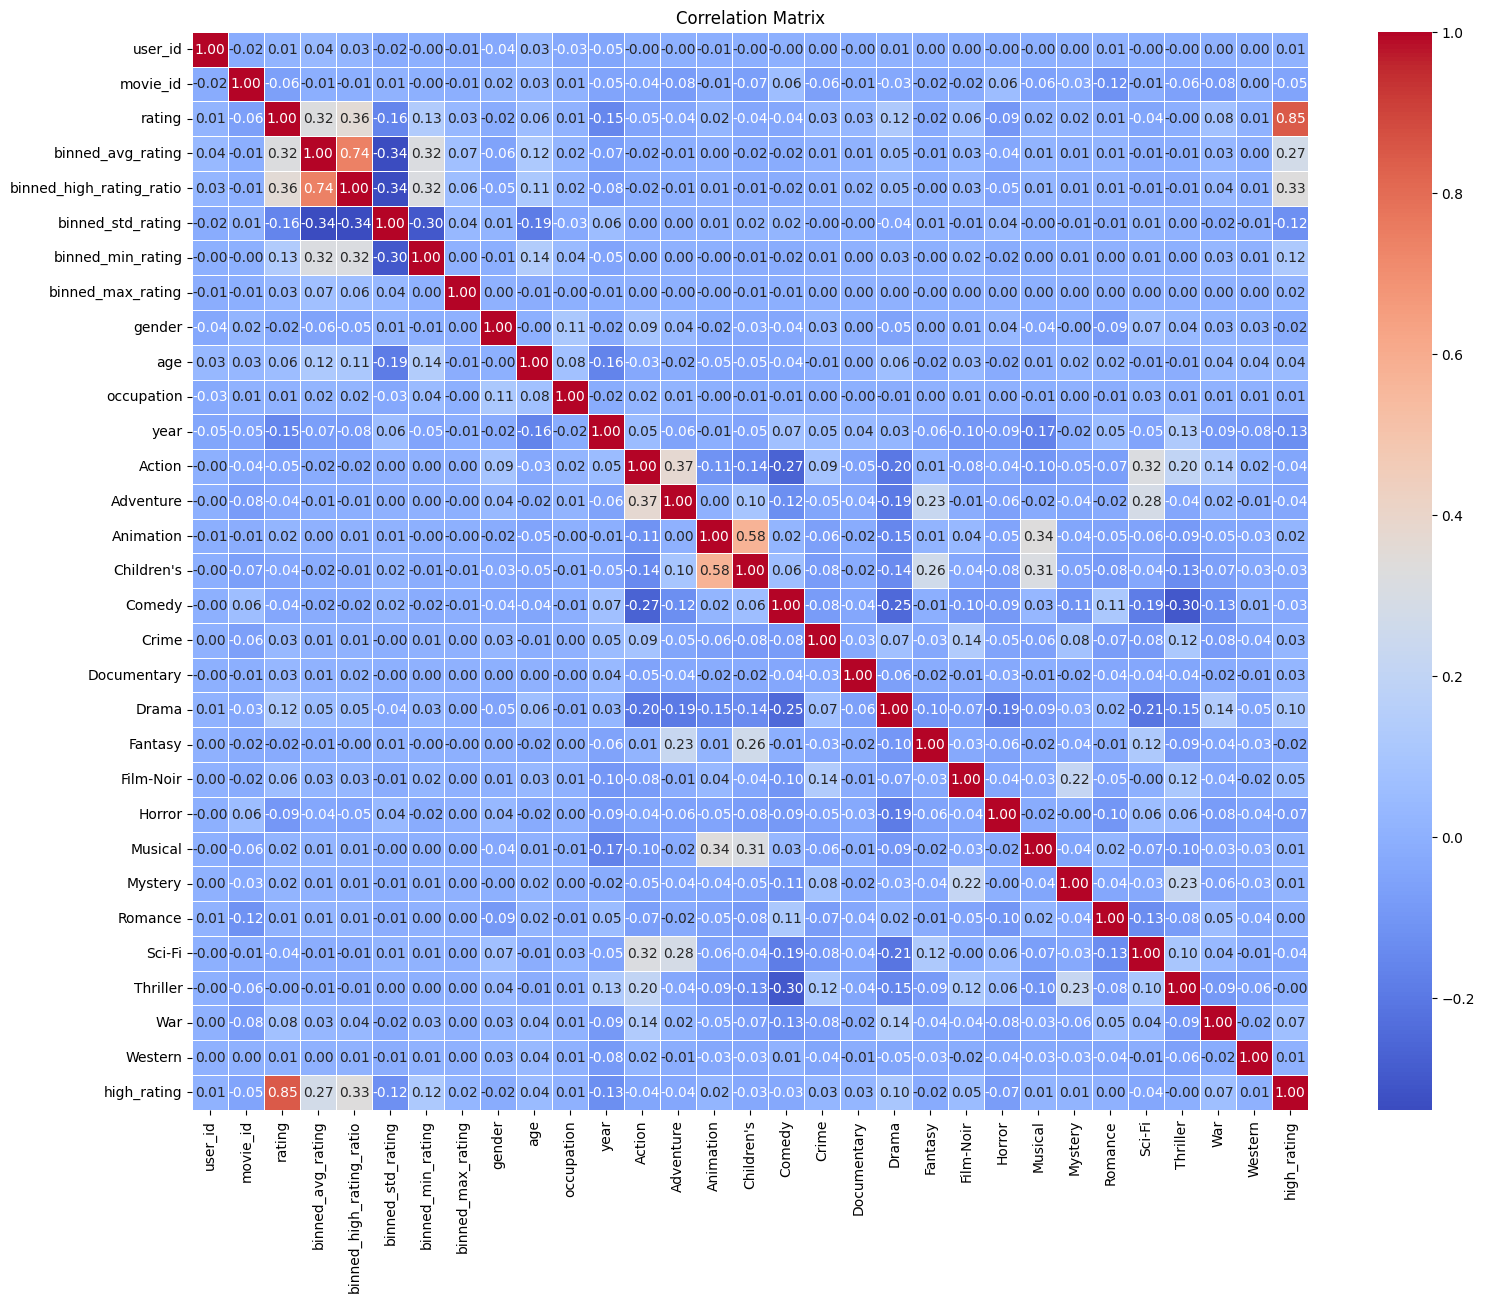

In [293]:
coor_matrix = full_data.corr()
plt.figure(figsize=(18, 14))
sns.heatmap(coor_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [133]:
train_data.columns

Index(['user_id', 'movie_id', 'rating', 'binned_avg_rating',
       'binned_high_rating_ratio', 'binned_std_rating', 'binned_min_rating',
       'binned_max_rating', 'gender', 'age', 'occupation', 'year', 'Action',
       'Adventure', 'Animation', 'Children's', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
       'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western',
       'high_rating'],
      dtype='object')

In [134]:
train_data_encoded = train_data.copy()

for col in train_data_encoded.columns:
    if train_data_encoded[col].dtype in ['bool', 'category']:
        train_data_encoded[col] = train_data_encoded[col].astype(int)


In [135]:
train_data_encoded["year"]

416292    0
683230    2
2434      2
688533    1
472584    2
         ..
259178    0
365838    2
131932    1
671155    1
121958    2
Name: year, Length: 800167, dtype: int64

In [ ]:

# est = PC(data=train_data_encoded)

# model = est.estimate(ci_test='g_sq')

# model.fit(train_data_encoded, estimator=MaximumLikelihoodEstimator)

# print(" Bayesian network trained successfully using G-Squared CI test.")


In [137]:
train_data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800167 entries, 416292 to 121958
Data columns (total 31 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   user_id                   800167 non-null  int64
 1   movie_id                  800167 non-null  int64
 2   rating                    800167 non-null  int64
 3   binned_avg_rating         800167 non-null  int64
 4   binned_high_rating_ratio  800167 non-null  int64
 5   binned_std_rating         800167 non-null  int64
 6   binned_min_rating         800167 non-null  int64
 7   binned_max_rating         800167 non-null  int64
 8   gender                    800167 non-null  int64
 9   age                       800167 non-null  int64
 10  occupation                800167 non-null  int64
 11  year                      800167 non-null  int64
 12  Action                    800167 non-null  int64
 13  Adventure                 800167 non-null  int64
 14  Animation           

In [138]:
train_data_encoded

,user_id,movie_id,rating,binned_avg_rating,binned_high_rating_ratio,binned_std_rating,binned_min_rating,binned_max_rating,gender,age,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,high_rating
416292,2507,3035,2,4,4,3,1,5,1,25,...,0,0,0,0,0,0,0,1,0,0
683230,4087,2840,4,3,2,3,1,5,1,1,...,0,0,0,0,0,0,1,0,0,1
2434,19,457,3,4,3,3,1,5,1,1,...,0,0,0,0,0,0,1,0,0,0
688533,4118,2804,4,5,4,2,1,5,1,25,...,0,0,0,0,0,0,0,0,0,1
472584,2907,805,4,4,2,3,1,5,0,35,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,1586,1077,5,5,5,2,2,5,1,45,...,0,0,0,0,0,1,0,0,0,1
365838,2129,2700,5,4,3,3,1,5,1,25,...,0,0,0,0,0,0,0,0,0,1
131932,854,3102,3,4,2,2,1,5,0,25,...,0,0,0,0,0,0,1,0,0,0
671155,4033,3479,5,4,4,3,1,5,1,25,...,0,0,0,0,1,0,0,0,0,1


In [139]:
train_data_encoded

,user_id,movie_id,rating,binned_avg_rating,binned_high_rating_ratio,binned_std_rating,binned_min_rating,binned_max_rating,gender,age,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,high_rating
416292,2507,3035,2,4,4,3,1,5,1,25,...,0,0,0,0,0,0,0,1,0,0
683230,4087,2840,4,3,2,3,1,5,1,1,...,0,0,0,0,0,0,1,0,0,1
2434,19,457,3,4,3,3,1,5,1,1,...,0,0,0,0,0,0,1,0,0,0
688533,4118,2804,4,5,4,2,1,5,1,25,...,0,0,0,0,0,0,0,0,0,1
472584,2907,805,4,4,2,3,1,5,0,35,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,1586,1077,5,5,5,2,2,5,1,45,...,0,0,0,0,0,1,0,0,0,1
365838,2129,2700,5,4,3,3,1,5,1,25,...,0,0,0,0,0,0,0,0,0,1
131932,854,3102,3,4,2,2,1,5,0,25,...,0,0,0,0,0,0,1,0,0,0
671155,4033,3479,5,4,4,3,1,5,1,25,...,0,0,0,0,1,0,0,0,0,1


code for HillClimbSearch 

In [ ]:

# hc = HillClimbSearch(train_df)
# model = hc.estimate(scoring_method=BDeuScore(train_df), max_indegree=2)
# bn_model = BayesianNetwork(model.edges())
# bn_model.fit(train_df, estimator=BayesianEstimator, prior_type="BDeu")

In [ ]:


 edges = [
    ('age', 'high_rating'),
    ('gender', 'high_rating'),
    ('occupation', 'high_rating'),

    ('binned_max_rating','high_rating'),
    ('binned_min_rating','high_rating'),
    ('year', 'high_rating'),

    ('binned_std_rating','high_rating'),
    ('binned_avg_rating', 'high_rating'),
    ('binned_high_rating_ratio', 'high_rating'),

    ('Action','high_rating'),
    ('Drama','high_rating'),
    ('Comedy','high_rating'),
    ('War','high_rating'),
    ('Horror','high_rating'),
    ('Drama','high_rating'),
    ('Film-Noir','high_rating'),
    ('Sci-Fi','high_rating'),
    ('Adventure','high_rating'),
    ('Musical','high_rating'),
    ('Mystery','high_rating'),
    ('Fantasy','high_rating'),
    ('Animation','high_rating'),
    ("Children's",'high_rating'),
    ('Western','high_rating'),
    ('Documentary','high_rating'),



 
]




model = DiscreteBayesianNetwork (edges)
model.fit(train_data_encoded, estimator=MaximumLikelihoodEstimator)



In [141]:
test_data.iloc[0]

user_id                                                             5412
movie_id                                                            2683
rating                                                                 2
binned_avg_rating                                                      4
binned_high_rating_ratio                                               4
binned_std_rating                                                      3
binned_min_rating                                                      1
binned_max_rating                                                      5
gender                                                                 1
age                                                                   25
occupation                                                            12
year                                                                   2
title                       Austin Powers: The Spy Who Shagged Me (1999)
Action                                             

In [143]:
test_data.columns

Index(['user_id', 'movie_id', 'rating', 'binned_avg_rating',
       'binned_high_rating_ratio', 'binned_std_rating', 'binned_min_rating',
       'binned_max_rating', 'gender', 'age', 'occupation', 'year', 'title',
       'Action', 'Adventure', 'Animation', 'Children's', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
       'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western',
       'high_rating'],
      dtype='object')

In [144]:
X_test = test_data.drop(columns=['high_rating',"user_id",'movie_id','rating', 'Adventure', 'Animation',
       "Children's", 'Crime', 'Documentary', 'Fantasy',
         'Musical', 'Mystery', 'Romance', 
       'Thriller', 'Western', 'high_rating','Sci-Fi'])
X_test=X_test[:900].drop(columns=["title"])


In [417]:
def build_evidence(user_profile, movie_row, genre_columns):
    evidence = user_profile.copy()
    for genre in genre_columns:
        evidence[genre] = movie_row[genre]
    return evidence


def get_movie_recommendations(movies_df, user_profile, genre_columns, infer, top_n=15):
    recommendations = []

    for _, row in movies_df.iterrows():
        evidence = build_evidence(user_profile, row, genre_columns)
        result = infer.query(variables=['high_rating'], evidence=evidence)
        prob = result.values[1]
        recommendations.append((row['title'], prob))

    sorted_movies = sorted(recommendations, key=lambda x: x[1], reverse=True)[:top_n]
    return sorted_movies


def filter_movies_by_genres(movies_df, selected_genres, logic='and'):

    if not selected_genres:
        return movies_df  

    condition = (movies_df[selected_genres[0]] == 1)

    for genre in selected_genres[1:]:
        if logic == 'and':
            condition = condition & (movies_df[genre] == 1)
        elif logic == 'or':
            condition = condition | (movies_df[genre] == 1)
        else:
            raise ValueError("logic must be 'and' or 'or'")

    return movies_df[condition]

In [436]:
genre_columns = ['Comedy', 'Drama', 'War', 'Horror', 'Film-Noir', 'Adventure']


In [437]:
selected_genres = ['Comedy', 'Drama']

logic_mode = 'and'  

movie_candidates = filter_movies_by_genres(movies, selected_genres, logic=logic_mode)

user_profile = {
    'age': 25,
    'gender': 0,
    'occupation': 4,
}


top5 = get_movie_recommendations(movie_candidates, user_profile, genre_columns, infer, top_n=5)

for title, prob in top5:
    print(f"{title}: prob high_rating = {prob:.2f}")

Waiting to Exhale (1995): prob high_rating = 0.61
American President, The (1995): prob high_rating = 0.61
Get Shorty (1995): prob high_rating = 0.61
Babe (1995): prob high_rating = 0.61
To Die For (1995): prob high_rating = 0.61


In [ ]:
movies[movies['title']=='Waiting to Exhale (1995)'][["Drama","Comedy"]]


,Drama,Comedy
3,True,True


In [464]:
movies[movies['title']=='American President, The (1995)'][["Drama","Comedy"]]


,Drama,Comedy
10,True,True


In [465]:
movies[movies['title']=='Get Shorty (1995)'][["Drama","Comedy"]]


,Drama,Comedy
20,True,True


In [466]:
movies[movies['title']=='Get Shorty (1995)'][["Drama","Comedy"]]


,Drama,Comedy
20,True,True


In [467]:
movies[movies['title']=='To Die For (1995)'][["Drama","Comedy"]]


,Drama,Comedy
44,True,True


In [ ]:
filtered_movies = movies_df[(movies_df['Comedy'] == 1) | (movies_df['Romance'] == 1)]

In [159]:
def precision_at_k(predicted, actual, k):
    predicted_k = predicted[:k]
    relevant = set(predicted_k) & set(actual)
    return len(relevant) / k

def recall_at_k(predicted, actual, k):
    predicted_k = predicted[:k]
    relevant = set(predicted_k) & set(actual)
    return len(relevant) / len(actual) if actual else 0

In [ ]:
k = 10
user_groups = test_data.groupby('user_id')
precisions = []
recalls = []

for user_id, group in user_groups:
    actual_positive_movies = group[group['high_rating'] == 1]['movie_id'].tolist()

    predictions = []
    for _, row in group.iterrows():
        evidence = {
            'age': row['age'],
            'gender': row['gender'],
            'occupation': row['occupation'],
            'year': row['year'],
            'binned_max_rating': row['binned_max_rating'],
            'binned_min_rating': row['binned_min_rating'],
            'binned_avg_rating': row['binned_avg_rating'],
            'binned_std_rating': row['binned_std_rating'],
            'binned_high_rating_ratio': row['binned_high_rating_ratio'],
            'Action': row.get('Action', 0),
            'Comedy': row.get('Comedy', 0),
            'Drama': row.get('Drama', 0),
            'War': row.get('War', 0),
            'Horror': row.get('Horror', 0),
            'Film-Noir': row.get('Film-Noir', 0),
            'Adventure': row.get('Adventure', 0)
        }

        try:
            result = infer.query(variables=['high_rating'], evidence=evidence)
            prob = result.values[1]
        except:
            prob = 0  

        predictions.append((row['movie_id'], prob))

    top_k_predictions = [movie_id for movie_id, _ in sorted(predictions, key=lambda x: x[1], reverse=True)[:k]]

    def precision_at_k(predicted, actual, k):
        predicted_k = predicted[:k]
        relevant = set(predicted_k) & set(actual)
        return len(relevant) / k

    def recall_at_k(predicted, actual, k):
        predicted_k = predicted[:k]
        relevant = set(predicted_k) & set(actual)
        return len(relevant) / len(actual) if actual else 0

    p_at_k = precision_at_k(top_k_predictions, actual_positive_movies, k)
    r_at_k = recall_at_k(top_k_predictions, actual_positive_movies, k)

    precisions.append(p_at_k)
    recalls.append(r_at_k)

average_precision = sum(precisions) / len(precisions)
average_recall = sum(recalls) / len(recalls)

print(f" Average Precision@{k}: {average_precision:.2f}")
print(f" Average Recall@{k}: {average_recall:.2f}")

 Average Precision@20: 0.48
 Average Recall@20: 0.77


k=5 => Precision@5: 0.67, Recall@5: 0.39
k=10 => Precision@10: 0.60, Recall@10: 0.59
k=15 => Precision@15: 0.53, Recall@15: 0.70
k=20 => Precision@20: 0.48, Recall@20: 0.77
k=25 => Precision@25: 0.44, Recall@25: 0.82


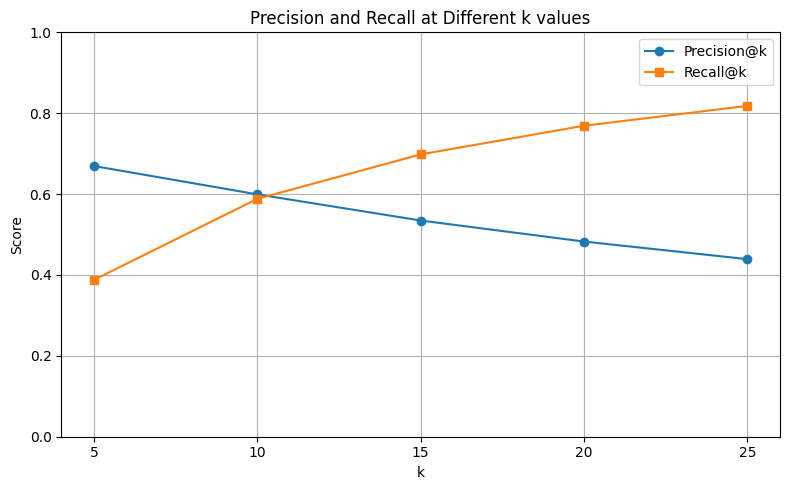

In [471]:
k_values = [5, 10, 15, 20,25]
precision_results = []
recall_results = []

for k in k_values:
    precisions = []
    recalls = []

    user_groups = test_data.groupby('user_id')

    for user_id, group in user_groups:
        actual_positive_movies = group[group['high_rating'] == 1]['movie_id'].tolist()

        predictions = []
        for _, row in group.iterrows():
            evidence = {
                'age': row['age'],
                'gender': row['gender'],
                'occupation': row['occupation'],
                'year': row['year'],
                'binned_max_rating': row['binned_max_rating'],
                'binned_min_rating': row['binned_min_rating'],
                'binned_avg_rating': row['binned_avg_rating'],
                'binned_std_rating': row['binned_std_rating'],
                'binned_high_rating_ratio': row['binned_high_rating_ratio'],
                'Action': row.get('Action', 0),
                'Comedy': row.get('Comedy', 0),
                'Drama': row.get('Drama', 0),
                'War': row.get('War', 0),
                'Horror': row.get('Horror', 0),
                'Film-Noir': row.get('Film-Noir', 0),
                'Adventure': row.get('Adventure', 0)
            }

            try:
                result = infer.query(variables=['high_rating'], evidence=evidence)
                prob = result.values[1]
            except:
                prob = 0

            predictions.append((row['movie_id'], prob))

        top_k_predictions = [movie_id for movie_id, _ in sorted(predictions, key=lambda x: x[1], reverse=True)[:k]]

        def precision_at_k(predicted, actual, k):
            predicted_k = predicted[:k]
            relevant = set(predicted_k) & set(actual)
            return len(relevant) / k

        def recall_at_k(predicted, actual, k):
            predicted_k = predicted[:k]
            relevant = set(predicted_k) & set(actual)
            return len(relevant) / len(actual) if actual else 0

        p_at_k = precision_at_k(top_k_predictions, actual_positive_movies, k)
        r_at_k = recall_at_k(top_k_predictions, actual_positive_movies, k)

        precisions.append(p_at_k)
        recalls.append(r_at_k)

    average_precision = sum(precisions) / len(precisions)
    average_recall = sum(recalls) / len(recalls)

    precision_results.append(average_precision)
    recall_results.append(average_recall)

    print(f"k={k} => Precision@{k}: {average_precision:.2f}, Recall@{k}: {average_recall:.2f}")


plt.figure(figsize=(8, 5))
plt.plot(k_values, precision_results, marker='o', label='Precision@k')
plt.plot(k_values, recall_results, marker='s', label='Recall@k')
plt.title('Precision and Recall at Different k values')
plt.xlabel('k')
plt.ylabel('Score')
plt.xticks(k_values)
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [163]:
train_data_encoded.groupby(['age', 'occupation', 'Drama'])['high_rating'].mean()

age  occupation  Drama
1    0           0        0.576883
                 1        0.702413
     1           0        0.539726
                 1        0.649718
     2           0        0.593496
                            ...   
56   18          1        0.662162
     19          0        0.500000
                 1        0.625767
     20          0        0.673575
                 1        0.864662
Name: high_rating, Length: 268, dtype: float64

In [479]:

demographic_profiles = [
    {
        'label': 'Student (age 18)',
        'evidence': {
            'age': 18,
            'occupation': 4,
            'gender': 0,  
            'year': 2,   

            'binned_max_rating': 5,
            'binned_min_rating': 1,
            'binned_avg_rating': 3,
            'binned_std_rating': 3,
            'binned_high_rating_ratio': 3

        }
    },
    {
        'label': 'academic (age 25)',
        'evidence': {
            'age': 25,
            'occupation': 1,
            'gender': 0,

            'year': 2,   

            'binned_max_rating': 5,
            'binned_min_rating': 1,
            'binned_avg_rating': 3,
            'binned_std_rating': 3,
            'binned_high_rating_ratio': 2
            

        }
        },


]

genres = ['Comedy', 'Drama', 'Action', 'Horror', 'War']

results = []

for profile in demographic_profiles:
    for genre in genres:
        evidence = profile['evidence'].copy()
        evidence[genre] = 1  

        try:
            result = infer.query(variables=['high_rating'], evidence=evidence)
            prob = result.values[1]
        except Exception:
            prob = None

        results.append({
            'Profile': profile['label'],
            'Genre': genre,
            'P(high_rating=1)': round(prob, 3) if prob is not None else 'Error'
        })

results_df = pd.DataFrame(results)
print(results_df)

             Profile   Genre  P(high_rating=1)
0   Student (age 18)  Comedy             0.587
1   Student (age 18)   Drama             0.715
2   Student (age 18)  Action             0.373
3   Student (age 18)  Horror             0.500
4   Student (age 18)     War             0.517
5  academic (age 25)  Comedy             0.364
6  academic (age 25)   Drama             0.516
7  academic (age 25)  Action             0.324
8  academic (age 25)  Horror             0.310
9  academic (age 25)     War             0.537


In [480]:

demographic_profiles = [
    {
        'label': 'Student (age 18)',
        'evidence': {
            'age': 18,
            'occupation': 4,
            'gender': 0,  
            'year': 2,   

            'binned_max_rating': 5,
            'binned_min_rating': 1,
            'binned_avg_rating': 3,
            'binned_std_rating': 3,
            'binned_high_rating_ratio': 3

        }
    },
    {
        'label': 'academic (age 18-25)',
        'evidence': {
            'age': 25,
            'occupation': 1,
            'gender': 0,

            'year': 2,   

            'binned_max_rating': 5,
            'binned_min_rating': 1,
            'binned_avg_rating': 3,
            'binned_std_rating': 3,
            'binned_high_rating_ratio': 2
            

        }
        },

    {
        'label': 'manager age 18-25)',
        'evidence': {
            'age': 25,
            'occupation': 7,
            'gender': 0,

            'year': 2,   

            'binned_max_rating': 5,
            'binned_min_rating': 1,
            'binned_avg_rating': 3,
            'binned_std_rating': 3,
            'binned_high_rating_ratio': 2
            

        }
    }
]

genres = ['Comedy', 'Drama', 'Action', 'Horror', 'War']

results = []

for profile in demographic_profiles:
    for genre in genres:
        evidence = profile['evidence'].copy()
        evidence[genre] = 1  

        try:
            result = infer.query(variables=['high_rating'], evidence=evidence)
            prob = result.values[1]
        except Exception:
            prob = None

        results.append({
            'Profile': profile['label'],
            'Genre': genre,
            'P(high_rating=1)': round(prob, 3) if prob is not None else 'Error'
        })

results_df = pd.DataFrame(results)
print(results_df)

                 Profile   Genre  P(high_rating=1)
0       Student (age 18)  Comedy             0.587
1       Student (age 18)   Drama             0.715
2       Student (age 18)  Action             0.373
3       Student (age 18)  Horror             0.500
4       Student (age 18)     War             0.517
5   academic (age 18-25)  Comedy             0.364
6   academic (age 18-25)   Drama             0.516
7   academic (age 18-25)  Action             0.324
8   academic (age 18-25)  Horror             0.310
9   academic (age 18-25)     War             0.537
10    manager age 18-25)  Comedy             0.436
11    manager age 18-25)   Drama             0.540
12    manager age 18-25)  Action             0.507
13    manager age 18-25)  Horror             0.354
14    manager age 18-25)     War             0.501


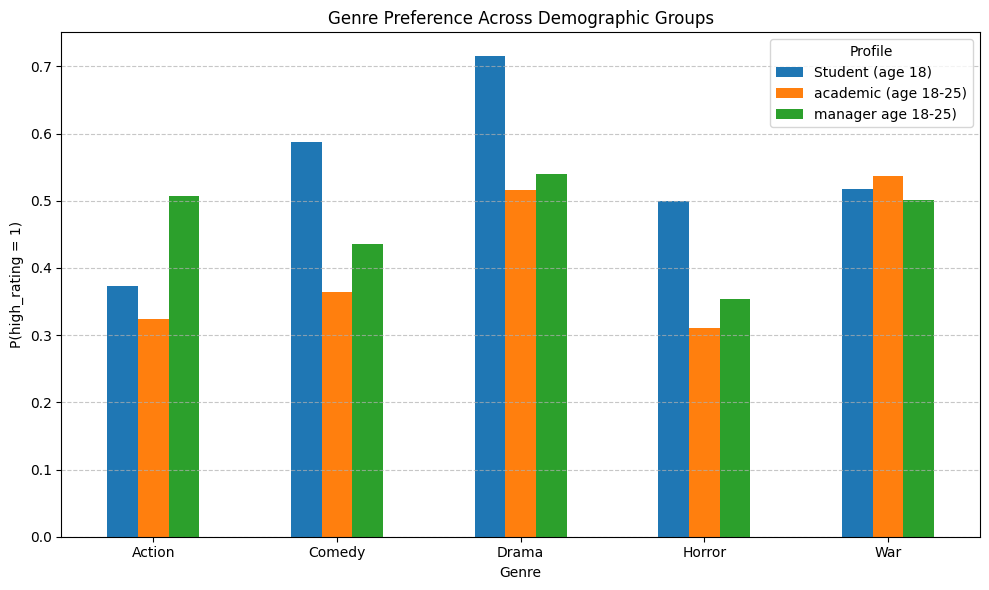

In [ ]:

plot_df = results_df.pivot(index='Genre', columns='Profile', values='P(high_rating=1)')

plot_df.plot(kind='bar', figsize=(10, 6))

plt.title('Genre Preference Across Demographic Groups')
plt.ylabel('P(high_rating = 1)')
plt.xlabel('Genre')
plt.xticks(rotation=0)
plt.legend(title='Profile')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [294]:
age_occ_counts = train_data.groupby(['age', 'occupation']).size().reset_index(name='count')

age_occ_counts = age_occ_counts.sort_values(by='count', ascending=False)

print(age_occ_counts[:10])

    age  occupation  count
17   18           4  70404
33   25           0  49754
40   25           7  34525
37   25           4  31304
34   25           1  27077
60   35           7  26235
49   25          17  24847
45   25          12  22001
52   25          20  20005
53   35           0  19458
